(162, 3)


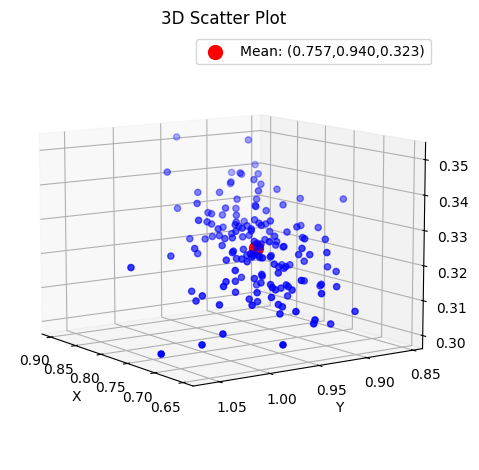

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting

datafolder = '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner_confidence/'
# points = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner/jupyter/ADAgrad_N50k_3/RSA_tuning_params.npy')
save_nm = 5
points = np.load(datafolder + f'params_final_{save_nm}.npy')
print(np.shape(points))

# points = all_params

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Unpack the three columns
x, y, z = points[:, 0], points[:, 1], points[:, 2]

xm, ym, zm = np.mean(x), np.mean(y), np.mean(z)

ax.scatter(x, y, z, marker='o', c='blue')  # 3D scatter plot
# put mean point in red big size over all other points making it stand out from others by being in front using the zorder
ax.scatter(xm, ym, zm, marker='o', c='red', s=100, zorder=0, label=f'Mean: ({xm:.3f},{ym:.3f},{zm:.3f})')  # Mean point
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Scatter Plot')
ax.view_init(elev=10, azim=145)
plt.tight_layout()
plt.legend()
plt.show()


(162, 101, 3)
[0.68001    0.6934035  0.69518167 0.690575   0.6871203 ] [0.98001    0.96393013 0.95780045 0.9555756  0.9521202 ] [0.33501    0.31952527 0.3162154  0.31591815 0.31508693]
[0.68001    0.70546705 0.72667056 0.7442955  0.7606946 ] [0.98001    0.95951915 0.9454034  0.93617874 0.92853576] [0.33501    0.3234747  0.32112026 0.3234584  0.327576  ]
[0.68001    0.71636146 0.72371274 0.7247692  0.7335879 ] [0.98001    0.94660586 0.9438403  0.94801    0.9446879 ] [0.33501    0.3000014  0.29766223 0.30496076 0.307134  ]
[0.68001    0.7072716  0.72225136 0.7358627  0.751128  ] [0.98001    0.9568611  0.94923794 0.94406366 0.93641573] [0.33501    0.31693935 0.31645268 0.31914178 0.31976485]
[0.68001   0.7052051 0.7162476 0.7248178 0.7339119] [0.98001    0.95588416 0.94795555 0.9440777  0.9411264 ] [0.33501    0.3117263  0.30687684 0.30810738 0.31136158]
[0.68001    0.7005811  0.7147917  0.71947676 0.7251683 ] [0.98001    0.960038   0.9488463  0.9508294  0.95410365] [0.33501    0.31754154

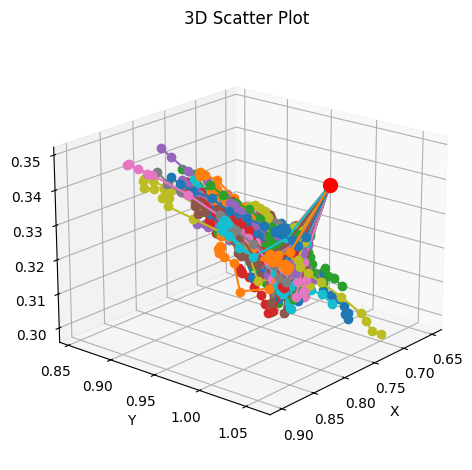

In [35]:
datafolder = '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner_confidence/'
# points = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner/jupyter/ADAgrad_N50k_3/RSA_tuning_params.npy')
all_points = np.load(datafolder + f'all_params_{save_nm}.npy')
print(np.shape(all_points))

# points = all_params
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for points in all_points:

    # Unpack the three columns
    x, y, z = points[::10, 0], points[::10, 1], points[::10, 2]

    ax.plot(x, y, z, marker='o')  # 3D scatter plot
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('3D Scatter Plot')
    ax.view_init(elev=15, azim=65)
    print(x[0:5], y[0:5], z[0:5])
plt.plot(x[0], y[0], z[0], marker='o', color='red', markersize=10)  # Start point
plt.tight_layout()
ax.view_init(elev=20, azim=40)
plt.show()


(163, 100)


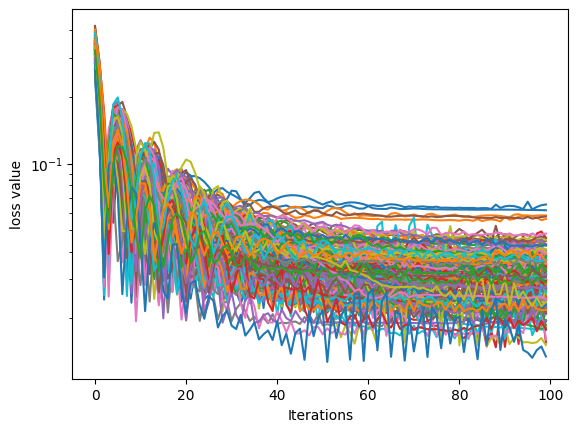

In [36]:
import matplotlib.pyplot as plt
datafolder = '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner_confidence/'
# points = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner/jupyter/ADAgrad_N50k_3/RSA_tuning_params.npy')
all_loss = np.load(datafolder + f'loss_values_{save_nm}.npy')

plt.figure()
print(np.shape(all_loss))
for loss in all_loss:
    plt.plot(loss)
plt.xlabel('Iterations')
plt.ylabel('loss value')
plt.yscale('log')

(180, 3)


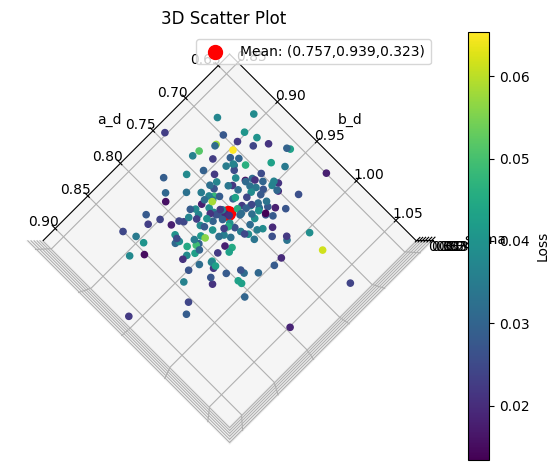

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting
from matplotlib import cm
from matplotlib.colors import Normalize


datafolder = '/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner_confidence/'
# points = np.load('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Tuner/jupyter/ADAgrad_N50k_3/RSA_tuning_params.npy')
save_nm = 5
points = np.load(datafolder + f'params_final_{save_nm}.npy')
all_loss = np.load(datafolder + f'loss_values_{save_nm}.npy')
loss_values_final = all_loss[:, -1]

norm = Normalize(vmin=np.min(loss_values_final), vmax=np.max(loss_values_final))
cmap = cm.viridis
colors = cmap(norm(loss_values_final))

print(np.shape(points))

# points = all_params

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Unpack the three columns
x, y, z = points[:, 0], points[:, 1], points[:, 2]

xm, ym, zm = np.mean(x), np.mean(y), np.mean(z)

ax.scatter(x, y, z, marker='o', c=colors, alpha=1)

# Create ScalarMappable for colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for older versions of matplotlib

# Add colorbar
cbar = plt.colorbar(sm, ax=ax, label='Loss')

# put mean point in red big size over all other points making it stand out from others by being in front using the zorder
ax.scatter(xm, ym, zm, marker='o', c='red', s=100, zorder=0, label=f'Mean: ({xm:.3f},{ym:.3f},{zm:.3f})')  # Mean point
ax.set_xlabel('a_d')
ax.set_ylabel('b_d')
ax.set_zlabel('sigma')
ax.set_title('3D Scatter Plot')
ax.view_init(elev=90, azim=45)
plt.tight_layout()
plt.legend()
plt.show()